In [1]:
import sys
sys.path.insert(0, '/home/lutein/Projects/class-gedf-test-04/build/temp.linux-x86_64-cpython-313')
import classy
print(classy.__file__)
import numpy as np

/home/lutein/anaconda3/envs/drdm/lib/python3.13/site-packages/classy/__init__.py


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import copy

# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, os
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'..')))
# from getdist import plots, MCSamples
# print('GetDist Version: %s, Matplotlib version: %s'%(getdist.__version__, plt.matplotlib.__version__))
import matplotlib.pyplot as plt
import IPython

from matplotlib import rcParams

config = {
    "font.family":'serif',
    "font.size": 15,
    # "mathtext.fontset":'stix',
    # "font.serif": ['SimSun'],
    "text.usetex": True,
    "savefig.dpi": 600,
    "xtick.direction": 'in',
    "ytick.direction": 'in'
}
rcParams.update(config)

In [17]:
model = classy.Class()

k = 1e-2  # 1/Mpc

model.set({'ln10^{10}A_s': 3.038, 
            'n_s': 0.99, 
            # 'H0': 73.62, # Do not use theta_s as input parameter. A bug to be fixed.
            'theta_s_100': 1.041783,
            # 'h': 0.67810,
            'omega_b': 0.02233, 
            'omega_cdm': 0.1182, 
            'tau_reio': 0.05430842,
            # 'rho_edf': 0.,
            # 'rho_gedf': 351.49/2., # We set rho_gedf at ac (a critical redshift of EoS transition) as input parameter, and f_gedf as a derived parameter. Instead, we can modify the code to use f_gedf as input parameter and use shooting method to get rho_gedf.
            'f_gedf': 0.1, # The fraction of GEDF at a_ini_over_a_today_default, which is a very early time when the universe is radiation dominated. We use this parameter to control the amount of GEDF in the early universe, and it can be used to constrain the model with CMB data.
            'ac_gedf': 1./2500,
            # 'ac_gedf': 1./10000,
            's_a_gedf': 3., # A random number controlling the tanh function
            # 'cs2_drdm': 1.,
            'wi_edf': -1.,
            'wf_edf': 1.,
            # 'use_exp_gedf': 'no',
            # 'q_gedf': 20.0,
            # 'set_const_cs2': 'no',
            # 'cs2_gedf': 0.37,
            'f_gedf_2': 0.0,
            # 'ac_gedf_2': 1./9000.,
            # 'wi_gedf_2': -1.,
            # 'wf_gedf_2': 1.,
            # 's_a_gedf_2': 3.,
            'dadb_like': 'yes',
            'dadb_F_d': 0.30,
            'dadb_Delta_e': 0.0,
            'dadb_z_e': 3500.0,
            'dadb_p_e': 6.0,
            'dadb_Delta_l': 0.080,
            'dadb_z_l': 0.43,
            'dadb_p_l': 6.0,
            'dadb_epsilon_X': 0.25,
            'dadb_z_X': 0.08,
            'dadb_p_X': 20.0,
            'dadb_perturbation_mode': 'drag_only',
            'dadb_beta5': 0.50,
            'dadb_kC_hmpc': 0.05,
            'Theta_i_edf': np.pi - 1.,
            'k_output_values':k,
            'gauge':'synchronous',
            # 'gauge': 'newtonian',
            'background_verbose': 3.,
            'start_small_k_at_tau_c_over_tau_h': 0.000004,
            'a_ini_over_a_today_default': 1e-16,
            'has_gedf_perturbations': 'yes',
            # 'has_gedf_2_perturbations': 'yes',
            'l_max_scalars': 5000,
            # 'get_perturbations_in_current_gauge': 'yes',
            })
model.set({'output':'tCl,pCl,lCl,mPk','lensing':'yes','P_k_max_1/Mpc':3.0})
model.compute()

print(model.get_current_derived_parameters(['f_gedf'])['f_gedf']) 

Running CLASS version v3.3.3
Computing background
Chose ndf15 as generic_evolver
 -> age = 13.085236 Gyr
 -> conformal age = 13947.583667 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
     -> rho_gedf = 46.871029, ac_gedf = 0.000400
 -> radiation/matter equality at z = 4629.058093
    corresponding to conformal time = 86.511170 Mpc
 -> f_EDF = 3.07455e-315    
 -> Omega_EDF = 0               
 -> Omega_EDF_zc = 0               
 -> omega_axion_pheno = 0.000142277     
 -> ca2_i_gedf = -3              
 -> ca2_f_gedf = 1               
 -> f_GEDF(ac_gedf) = 0.0999999       
 -> rho_gedf/rho_tot(ac_gedf) = 0.0999999       
 ---------------------------- Budget equation ----------------------- 
 ---> Nonrelativistic Species 
-> Bayrons                        Omega = 0.0394434       , omega = 0.02233        
-> Cold Dark Matter               Omega = 0.146151        , omega = 0.08274        
-> DADB coupled dark matter       Omega = 0.0626361      

In [25]:
print(model.get_background().keys())
print(r"H0 value is", model.get_current_derived_parameters(['H0'])['H0'])
print(r"sigma8 value is", model.get_current_derived_parameters(['sigma8'])['sigma8'])

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', 'DADB M', 'DADB q', 'DADB w_X', '(.)rho_dadb_u', '(.)rho_dadb_d', '(.)rho_dadb_X', '(.)rho_dadb_eff', 'DADB w_eff', '(.)rho_gedf', '(.)w_gedf', '(.)rho_ur', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])
H0 value is 75.2414117199763
sigma8 value is 0.7790147934659104


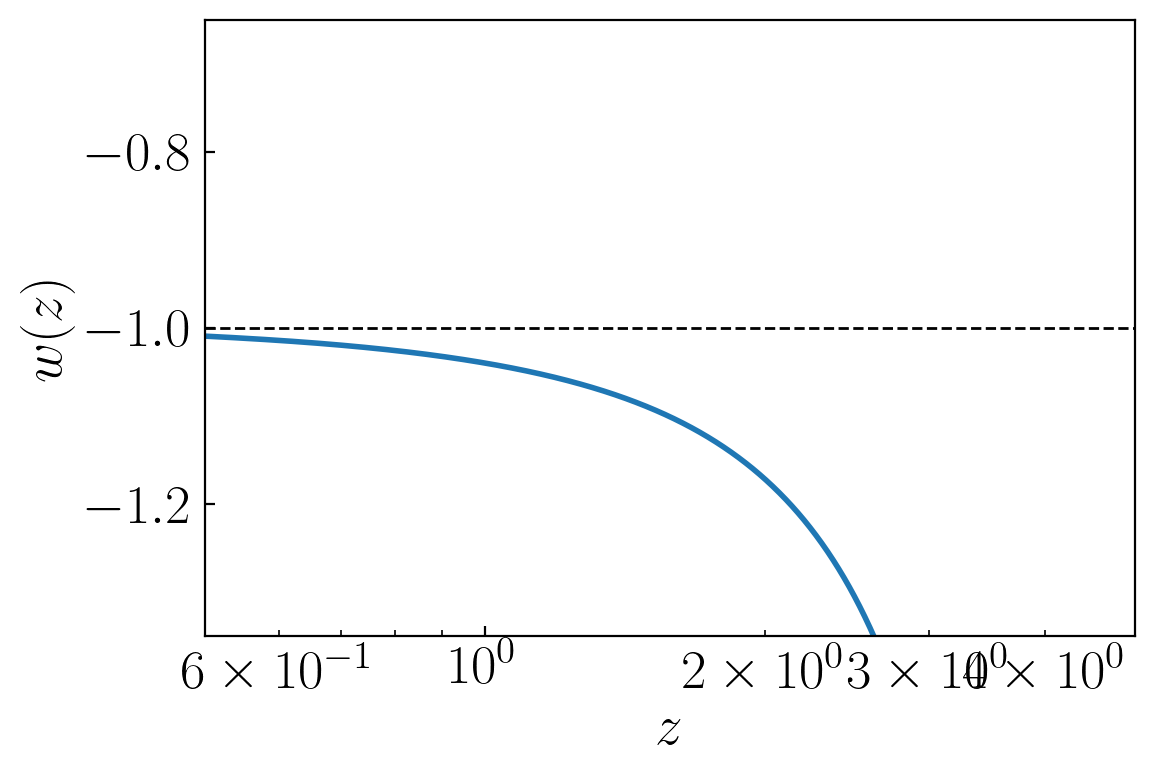

In [8]:
plt.figure(figsize=(6, 4))

bg = model.get_background()
good = ((bg['(.)rho_dadb_eff'] > 0)
        & np.isfinite(bg['DADB w_eff']))
plt.semilogx(bg['z'][good], 
             bg['DADB w_eff'][good],
            #  model.get_background()['(.)w_gedf'], 
            #  model.get_background()['(.)rho_dadb_eff']/model.get_background()['(.)rho_tot'], 
            #  model.get_background()['(.)rho_gedf']/model.get_background()['(.)rho_tot'], 
            #  model.get_background()['(.)rho_cdm']/model.get_background()['(.)rho_tot'], 
             '-', linewidth=2, label=r'test')
plt.xlabel(r'$z$')
plt.ylabel(r'$w(z)$')
plt.xlim([0.5e0, 5e0])
plt.ylim([-1.35, -0.65])
plt.axhline(-1, color='k', lw=1, ls='--')
plt.show()

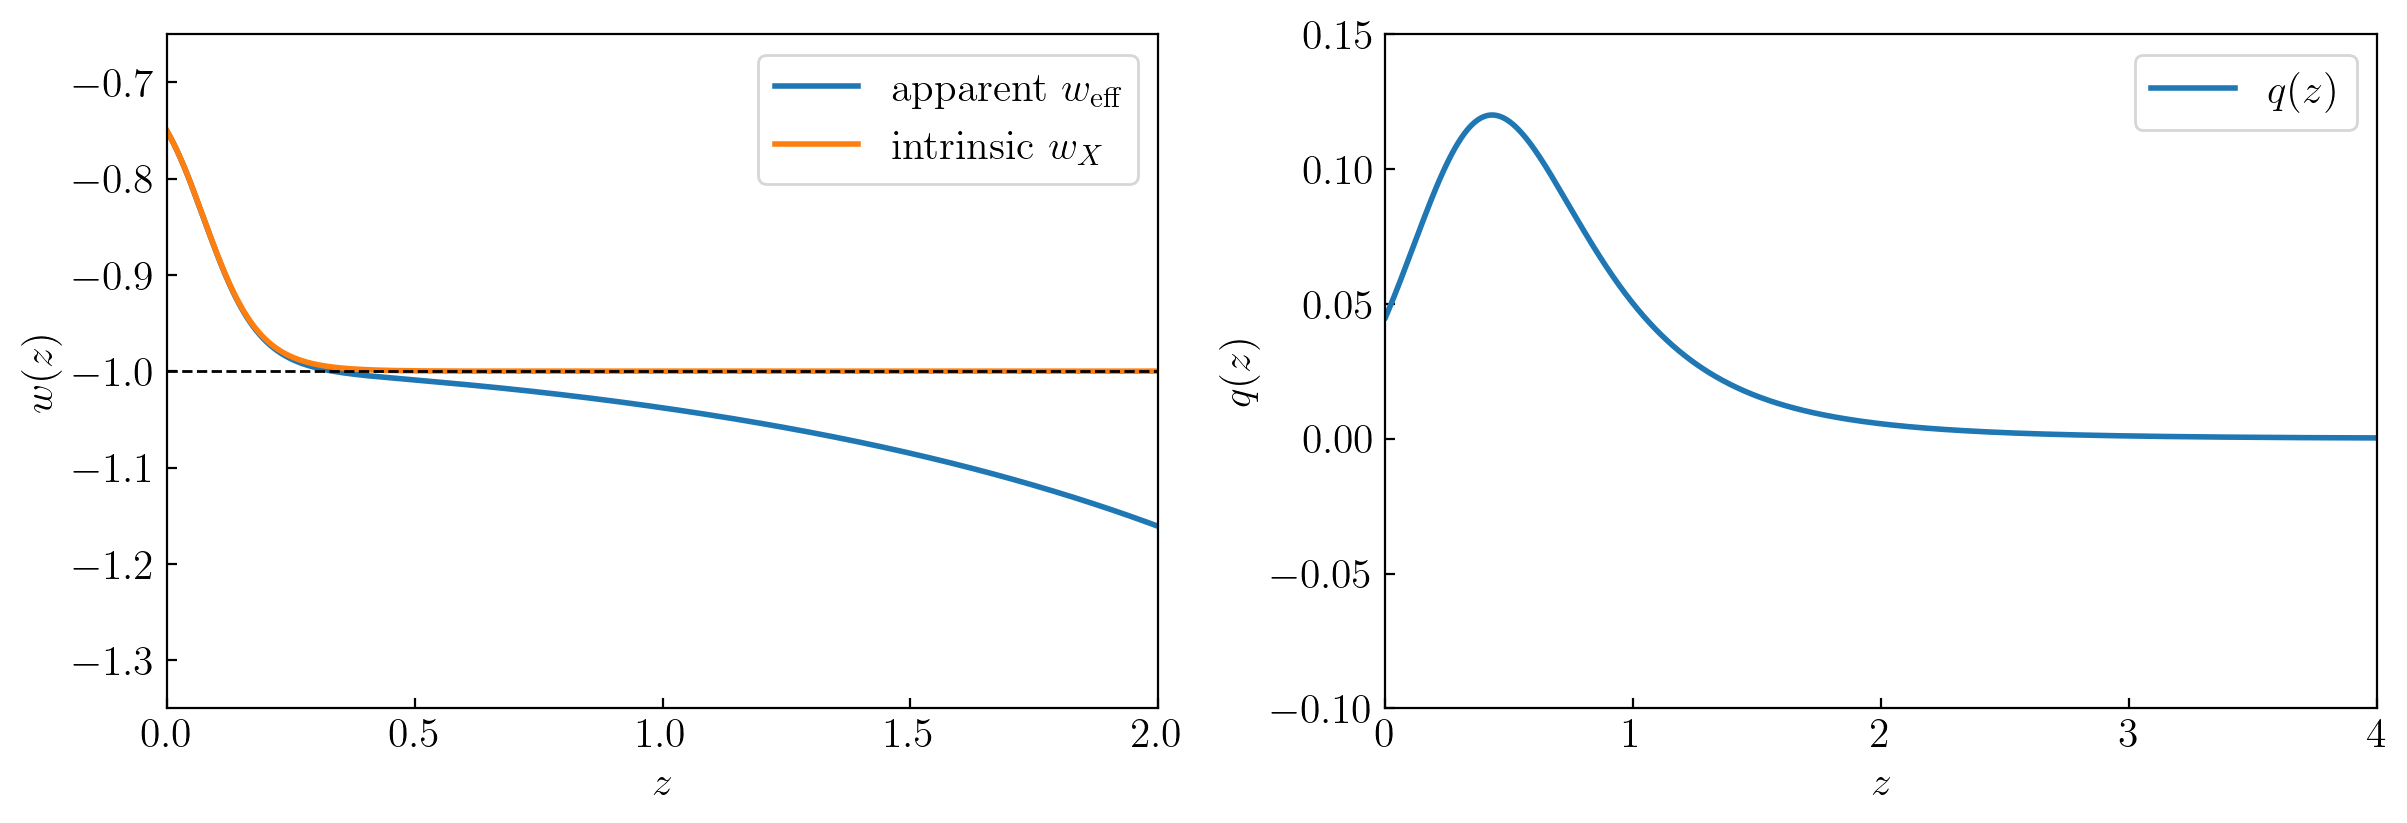

In [29]:
# plt.figure(figsize=(6, 4))
fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

bg = model.get_background()
# Checked that w_eff is finite for all z, so we can plot it without filtering

# good = ((bg['(.)rho_dadb_eff'] > 0)
#         & np.isfinite(bg['DADB w_eff']))
# plt.plot(bg['z'][good], 
#              bg['DADB w_eff'][good],
#              '-', linewidth=2, label=r'test')
ax[0].plot(bg['z'], 
             bg['DADB w_eff'],
             '-', linewidth=2, label=r"apparent $w_{\rm eff}$")
ax[0].plot(bg['z'], 
             bg['DADB w_X'],
             '-', linewidth=2, label=r"intrinsic $w_X$")
ax[0].set_xlabel(r'$z$')
ax[0].set_ylabel(r'$w(z)$')
ax[0].set_xlim([0, 2e0])
ax[0].set_ylim([-1.35, -0.65])
ax[0].axhline(-1, color='k', lw=1, ls='--')
ax[0].legend()

ax[1].plot(bg['z'],
             bg['DADB q'],
             '-', linewidth=2, label=r"$q(z)$")
ax[1].set_xlabel(r'$z$')
ax[1].set_ylabel(r'$q(z)$')
ax[1].set_xlim([0, 4e0])
ax[1].set_ylim([-0.1, 0.15])
# ax[1].axhline(-1, color='k', lw=1, ls='--')
ax[1].legend()

plt.show()

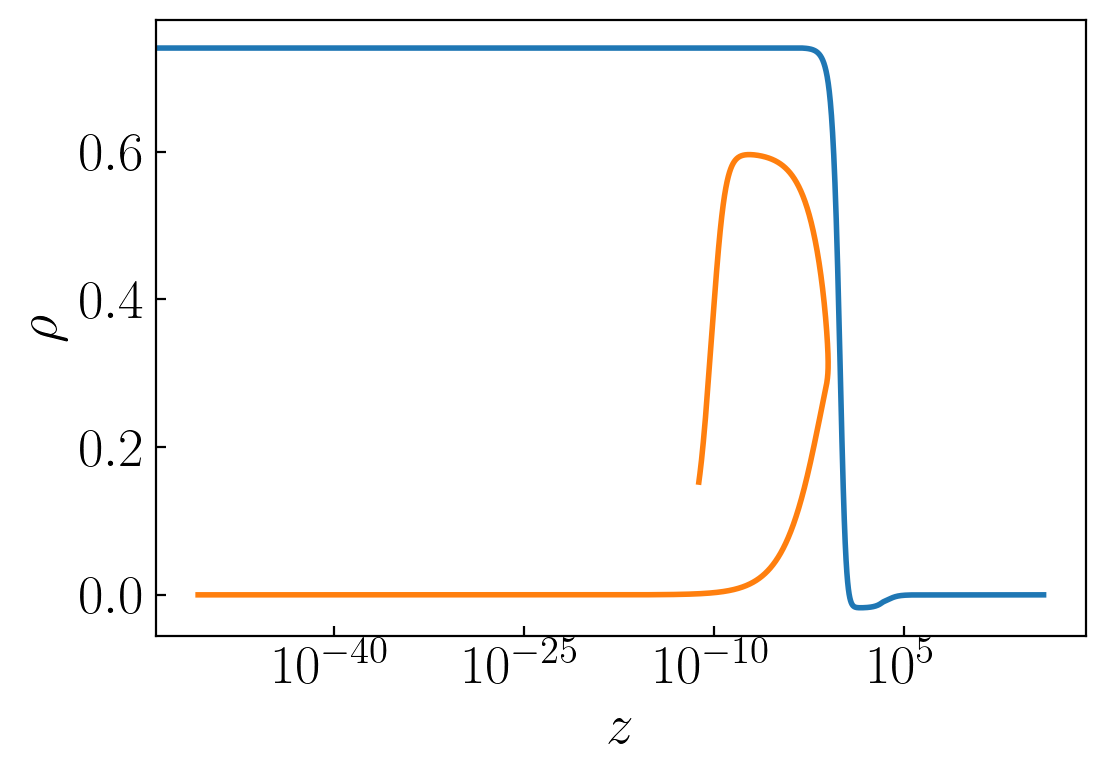

In [ ]:
plt.figure(figsize=(6, 4))

plt.semilogx(model.get_background()['z'], model.get_background()['(.)rho_dadb_eff']/model.get_background()['(.)rho_tot'], model.get_background()['(.)rho_gedf']/model.get_background()['(.)rho_tot'], model.get_background()['(.)rho_cdm']/model.get_background()['(.)rho_tot'], '-', linewidth=2, label=r'test')
plt.xlabel(r'$z$')
plt.ylabel(r'$\rho$')
# plt.ylabel(r'$w_{\mathrm{eff}}$')
# plt.xlim([1e0, 5e0])
plt.show()

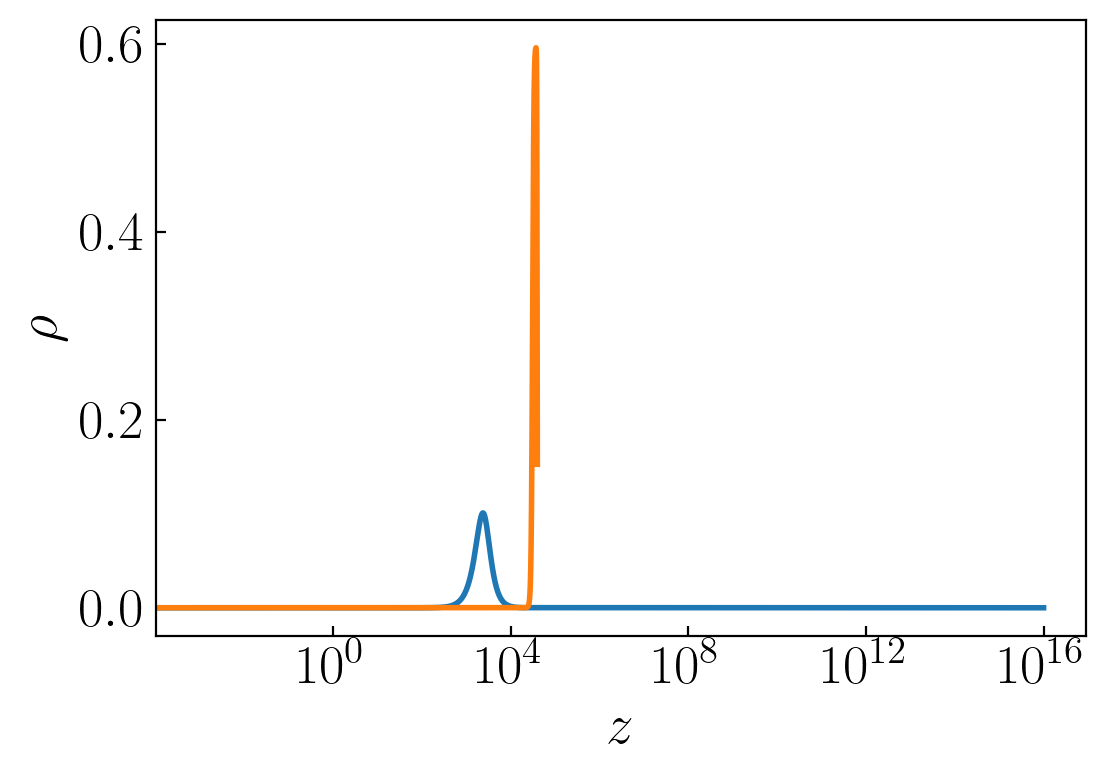

In [7]:
plt.figure(figsize=(6, 4))

plt.semilogx(model.get_background()['z'], model.get_background()['(.)rho_gedf']/model.get_background()['(.)rho_tot'], model.get_background()['(.)rho_cdm']/model.get_background()['(.)rho_tot'], '-', linewidth=2, label=r'test')
plt.xlabel(r'$z$')
plt.ylabel(r'$\rho$')
# plt.ylabel(r'$w_{\mathrm{eff}}$')
# plt.xlim([1e0, 5e0])
# plt.axvline(x = 3646, color = 'gray', linestyle = '--', label=r'$z_{\mathrm{ac}}$')
plt.show()